In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV
)

RANDOM_STATE = 42

print("Regression libraries imported successfully!")

Regression libraries imported successfully!


In [2]:
df = pd.read_csv("../data/processed/f1_master_dataset_final.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (6911, 35)


,season,round,race_name,date,driver_id,driver_code,driver_name,constructor_id,constructor,number,...,avg_finish_last_5,avg_qualifying_last_5,season_points_so_far,season_wins_so_far,season_podiums_so_far,constructor_points_so_far,constructor_wins_so_far,constructor_podiums_so_far,career_races_before,podium
0,2010,1,Bahrain Grand Prix,2010-03-14,alguersuari,ALG,Jaime Alguersuari,toro_rosso,Toro Rosso,17,...,20.0,20.0,0.0,0,0,0.0,0,0,0,0
1,2010,1,Bahrain Grand Prix,2010-03-14,alonso,ALO,Fernando Alonso,ferrari,Ferrari,8,...,20.0,20.0,0.0,0,0,0.0,0,0,0,1
2,2010,1,Bahrain Grand Prix,2010-03-14,barrichello,BAR,Rubens Barrichello,williams,Williams,9,...,20.0,20.0,0.0,0,0,0.0,0,0,0,0
3,2010,1,Bahrain Grand Prix,2010-03-14,bruno_senna,SEN,Bruno Senna,hrt,HRT,21,...,20.0,20.0,0.0,0,0,0.0,0,0,0,0
4,2010,1,Bahrain Grand Prix,2010-03-14,buemi,BUE,Sébastien Buemi,toro_rosso,Toro Rosso,16,...,20.0,20.0,0.0,0,0,0.0,0,0,0,0


In [3]:
feature_columns = [
    "qualifying_position",
    "grid",
    "previous_finish",
    "avg_finish_all_previous",
    "avg_qualifying_all_previous",
    "avg_finish_last_5",
    "avg_qualifying_last_5",
    "season_points_so_far",
    "season_wins_so_far",
    "season_podiums_so_far",
    "constructor_points_so_far",
    "constructor_wins_so_far",
    "constructor_podiums_so_far",
    "career_races_before"
]

X = df[feature_columns].copy()
y = df["position"].copy()

print("Features:", X.shape)
print("Target:", y.shape)

Features: (6911, 14)
Target: (6911,)


In [4]:
train_mask = df["season"].between(2010, 2023)
validation_mask = df["season"] == 2024
test_mask = df["season"] == 2025

X_train = df.loc[train_mask, feature_columns].copy()
X_validation = df.loc[validation_mask, feature_columns].copy()
X_test = df.loc[test_mask, feature_columns].copy()

y_train = df.loc[train_mask, "position"].copy()
y_validation = df.loc[validation_mask, "position"].copy()
y_test = df.loc[test_mask, "position"].copy()

print("Training:", X_train.shape)
print("Validation:", X_validation.shape)
print("Testing:", X_test.shape)

Training: (5953, 14)
Validation: (479, 14)
Testing: (479, 14)


In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [6]:
# Linear Regression

linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)

# Predict on validation data
linear_val_pred = linear_model.predict(X_validation_scaled)

# Calculate metrics
linear_r2 = r2_score(y_validation, linear_val_pred)
linear_rmse = np.sqrt(mean_squared_error(y_validation, linear_val_pred))
linear_mae = mean_absolute_error(y_validation, linear_val_pred)

print("Linear Regression")
print("-----------------")
print("R²   :", round(linear_r2, 4))
print("RMSE :", round(linear_rmse, 4))
print("MAE  :", round(linear_mae, 4))

Linear Regression
-----------------
R²   : 0.5657
RMSE : 3.7931
MAE  : 2.9368


In [7]:
# Ridge Regression

ridge_model = Ridge(alpha=1.0)

# Train
ridge_model.fit(X_train_scaled, y_train)

# Predict on validation data
ridge_val_pred = ridge_model.predict(X_validation_scaled)

# Calculate metrics
ridge_r2 = r2_score(y_validation, ridge_val_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_validation, ridge_val_pred))
ridge_mae = mean_absolute_error(y_validation, ridge_val_pred)

print("Ridge Regression")
print("----------------")
print("R²   :", round(ridge_r2, 4))
print("RMSE :", round(ridge_rmse, 4))
print("MAE  :", round(ridge_mae, 4))

Ridge Regression
----------------
R²   : 0.5658
RMSE : 3.7928
MAE  : 2.9368


In [8]:
# Lasso Regression

lasso_model = Lasso(alpha=0.01, max_iter=10000)

# Train
lasso_model.fit(X_train_scaled, y_train)

# Predict on validation data
lasso_val_pred = lasso_model.predict(X_validation_scaled)

# Calculate metrics
lasso_r2 = r2_score(y_validation, lasso_val_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_validation, lasso_val_pred))
lasso_mae = mean_absolute_error(y_validation, lasso_val_pred)

print("Lasso Regression")
print("----------------")
print("R²   :", round(lasso_r2, 4))
print("RMSE :", round(lasso_rmse, 4))
print("MAE  :", round(lasso_mae, 4))

Lasso Regression
----------------
R²   : 0.567
RMSE : 3.7874
MAE  : 2.9472


In [9]:
# ElasticNet Regression

elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

# Train
elastic_model.fit(X_train_scaled, y_train)

# Predict on validation data
elastic_val_pred = elastic_model.predict(X_validation_scaled)

# Calculate metrics
elastic_r2 = r2_score(y_validation, elastic_val_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_validation, elastic_val_pred))
elastic_mae = mean_absolute_error(y_validation, elastic_val_pred)

print("ElasticNet Regression")
print("---------------------")
print("R²   :", round(elastic_r2, 4))
print("RMSE :", round(elastic_rmse, 4))
print("MAE  :", round(elastic_mae, 4))

ElasticNet Regression
---------------------
R²   : 0.5668
RMSE : 3.7886
MAE  : 2.9439


In [10]:
# Polynomial Regression

polynomial_model = Pipeline([
    ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear_regression", LinearRegression())
])

# Train
polynomial_model.fit(X_train_scaled, y_train)

# Predict on validation data
polynomial_val_pred = polynomial_model.predict(X_validation_scaled)

# Calculate metrics
polynomial_r2 = r2_score(y_validation, polynomial_val_pred)
polynomial_rmse = np.sqrt(mean_squared_error(y_validation, polynomial_val_pred))
polynomial_mae = mean_absolute_error(y_validation, polynomial_val_pred)

print("Polynomial Regression")
print("---------------------")
print("R²   :", round(polynomial_r2, 4))
print("RMSE :", round(polynomial_rmse, 4))
print("MAE  :", round(polynomial_mae, 4))

Polynomial Regression
---------------------
R²   : 0.5538
RMSE : 3.8449
MAE  : 3.0167


In [11]:
# Decision Tree Regression

decision_tree_model = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

# Train
decision_tree_model.fit(X_train, y_train)

# Predict on validation data
decision_tree_val_pred = decision_tree_model.predict(X_validation)

# Calculate metrics
decision_tree_r2 = r2_score(y_validation, decision_tree_val_pred)
decision_tree_rmse = np.sqrt(
    mean_squared_error(y_validation, decision_tree_val_pred)
)
decision_tree_mae = mean_absolute_error(
    y_validation, decision_tree_val_pred
)

print("Decision Tree Regression")
print("------------------------")
print("R²   :", round(decision_tree_r2, 4))
print("RMSE :", round(decision_tree_rmse, 4))
print("MAE  :", round(decision_tree_mae, 4))

Decision Tree Regression
------------------------
R²   : -0.2615
RMSE : 6.4649
MAE  : 4.8434


In [12]:
# Random Forest Regression

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train
random_forest_model.fit(X_train, y_train)

# Predict on validation data
random_forest_val_pred = random_forest_model.predict(X_validation)

# Calculate metrics
random_forest_r2 = r2_score(
    y_validation, random_forest_val_pred
)

random_forest_rmse = np.sqrt(
    mean_squared_error(y_validation, random_forest_val_pred)
)

random_forest_mae = mean_absolute_error(
    y_validation, random_forest_val_pred
)

print("Random Forest Regression")
print("------------------------")
print("R²   :", round(random_forest_r2, 4))
print("RMSE :", round(random_forest_rmse, 4))
print("MAE  :", round(random_forest_mae, 4))

Random Forest Regression
------------------------
R²   : 0.5095
RMSE : 4.0311
MAE  : 3.166


In [13]:
# Gradient Boosting Regression

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

# Train
gradient_boosting_model.fit(X_train, y_train)

# Predict on validation data
gradient_boosting_val_pred = gradient_boosting_model.predict(X_validation)

# Calculate metrics
gradient_boosting_r2 = r2_score(
    y_validation, gradient_boosting_val_pred
)

gradient_boosting_rmse = np.sqrt(
    mean_squared_error(y_validation, gradient_boosting_val_pred)
)

gradient_boosting_mae = mean_absolute_error(
    y_validation, gradient_boosting_val_pred
)

print("Gradient Boosting Regression")
print("----------------------------")
print("R²   :", round(gradient_boosting_r2, 4))
print("RMSE :", round(gradient_boosting_rmse, 4))
print("MAE  :", round(gradient_boosting_mae, 4))

Gradient Boosting Regression
----------------------------
R²   : 0.5317
RMSE : 3.9389
MAE  : 3.099


In [14]:
# Support Vector Regression

svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1
)

# Train
svr_model.fit(X_train_scaled, y_train)

# Predict on validation data
svr_val_pred = svr_model.predict(X_validation_scaled)

# Calculate metrics
svr_r2 = r2_score(y_validation, svr_val_pred)

svr_rmse = np.sqrt(
    mean_squared_error(y_validation, svr_val_pred)
)

svr_mae = mean_absolute_error(
    y_validation, svr_val_pred
)

print("Support Vector Regression (SVR)")
print("-------------------------------")
print("R²   :", round(svr_r2, 4))
print("RMSE :", round(svr_rmse, 4))
print("MAE  :", round(svr_mae, 4))

Support Vector Regression (SVR)
-------------------------------
R²   : 0.4312
RMSE : 4.341
MAE  : 3.1816


In [15]:
# KNN Regression

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

# Train
knn_model.fit(X_train_scaled, y_train)

# Predict on validation data
knn_val_pred = knn_model.predict(X_validation_scaled)

# Calculate metrics
knn_r2 = r2_score(y_validation, knn_val_pred)

knn_rmse = np.sqrt(
    mean_squared_error(y_validation, knn_val_pred)
)

knn_mae = mean_absolute_error(
    y_validation, knn_val_pred
)

print("KNN Regression")
print("--------------")
print("R²   :", round(knn_r2, 4))
print("RMSE :", round(knn_rmse, 4))
print("MAE  :", round(knn_mae, 4))

KNN Regression
--------------
R²   : 0.4362
RMSE : 4.3218
MAE  : 3.3712


In [16]:
# Regression Model Comparison

regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression",
        "Polynomial Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR",
        "KNN"
    ],
    
    "R²": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2,
        polynomial_r2,
        decision_tree_r2,
        random_forest_r2,
        gradient_boosting_r2,
        svr_r2,
        knn_r2
    ],
    
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse,
        polynomial_rmse,
        decision_tree_rmse,
        random_forest_rmse,
        gradient_boosting_rmse,
        svr_rmse,
        knn_rmse
    ],
    
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae,
        polynomial_mae,
        decision_tree_mae,
        random_forest_mae,
        gradient_boosting_mae,
        svr_mae,
        knn_mae
    ]
})

regression_results = regression_results.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

regression_results.round(4)

,Model,R²,RMSE,MAE
0,Lasso Regression,0.5670,3.7874,2.9472
1,ElasticNet Regression,0.5668,3.7886,2.9439
2,Ridge Regression,0.5658,3.7928,2.9368
3,Linear Regression,0.5657,3.7931,2.9368
4,Polynomial Regression,0.5538,3.8449,3.0167
5,Gradient Boosting,0.5317,3.9389,3.0990
6,Random Forest,0.5095,4.0311,3.1660
7,KNN,0.4362,4.3218,3.3712
8,SVR,0.4312,4.3410,3.1816
9,Decision Tree,-0.2615,6.4649,4.8434


In [17]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, ElasticNet

# 5-fold chronological cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Lasso pipeline
lasso_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

# ElasticNet pipeline
elastic_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=0.01,
        l1_ratio=0.5,
        max_iter=10000
    ))
])

# Lasso CV
lasso_cv_scores = cross_val_score(
    lasso_cv_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="r2"
)

# ElasticNet CV
elastic_cv_scores = cross_val_score(
    elastic_cv_model,
    X_train,
    y_train,
    cv=tscv,
    scoring="r2"
)

print("Lasso 5-Fold CV R² Scores:")
print(np.round(lasso_cv_scores, 4))
print("Mean CV R²:", round(lasso_cv_scores.mean(), 4))

print("\nElasticNet 5-Fold CV R² Scores:")
print(np.round(elastic_cv_scores, 4))
print("Mean CV R²:", round(elastic_cv_scores.mean(), 4))

Lasso 5-Fold CV R² Scores:
[0.3846 0.4432 0.4062 0.4007 0.4265]
Mean CV R²: 0.4122

ElasticNet 5-Fold CV R² Scores:
[0.3884 0.4438 0.4078 0.4006 0.4259]
Mean CV R²: 0.4133


In [18]:
from sklearn.model_selection import GridSearchCV

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000))
])

lasso_param_grid = {
    "model__alpha": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso Parameters:")
print(lasso_grid.best_params_)

print("\nBest Lasso CV R²:")
print(round(lasso_grid.best_score_, 4))

Best Lasso Parameters:
{'model__alpha': 0.05}

Best Lasso CV R²:
0.415


In [19]:
# ElasticNet Hyperparameter Tuning

elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000))
])

elastic_param_grid = {
    "model__alpha": [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

elastic_grid.fit(X_train, y_train)

print("Best ElasticNet Parameters:")
print(elastic_grid.best_params_)

print("\nBest ElasticNet CV R²:")
print(round(elastic_grid.best_score_, 4))

Best ElasticNet Parameters:
{'model__alpha': 0.05, 'model__l1_ratio': 0.9}

Best ElasticNet CV R²:
0.4151


In [20]:
# Evaluate tuned models on 2024 validation data

# Lasso
tuned_lasso_val_pred = lasso_grid.predict(X_validation)

tuned_lasso_r2 = r2_score(
    y_validation, tuned_lasso_val_pred
)

tuned_lasso_rmse = np.sqrt(
    mean_squared_error(y_validation, tuned_lasso_val_pred)
)

tuned_lasso_mae = mean_absolute_error(
    y_validation, tuned_lasso_val_pred
)


# ElasticNet
tuned_elastic_val_pred = elastic_grid.predict(X_validation)

tuned_elastic_r2 = r2_score(
    y_validation, tuned_elastic_val_pred
)

tuned_elastic_rmse = np.sqrt(
    mean_squared_error(y_validation, tuned_elastic_val_pred)
)

tuned_elastic_mae = mean_absolute_error(
    y_validation, tuned_elastic_val_pred
)


# Display results
tuned_results = pd.DataFrame({
    "Model": ["Tuned Lasso", "Tuned ElasticNet"],
    "R²": [tuned_lasso_r2, tuned_elastic_r2],
    "RMSE": [tuned_lasso_rmse, tuned_elastic_rmse],
    "MAE": [tuned_lasso_mae, tuned_elastic_mae]
})

display(tuned_results.round(4))

,Model,R²,RMSE,MAE
0,Tuned Lasso,0.5676,3.7849,2.9587
1,Tuned ElasticNet,0.5675,3.7856,2.9582


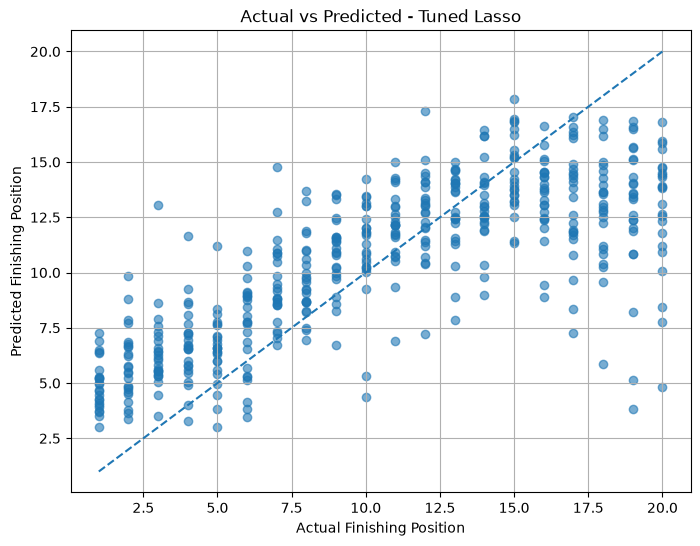

In [21]:
# Actual vs Predicted Plot

plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    tuned_lasso_val_pred,
    alpha=0.6
)

plt.plot(
    [y_validation.min(), y_validation.max()],
    [y_validation.min(), y_validation.max()],
    linestyle="--"
)

plt.xlabel("Actual Finishing Position")
plt.ylabel("Predicted Finishing Position")
plt.title("Actual vs Predicted - Tuned Lasso")
plt.grid(True)

plt.show()

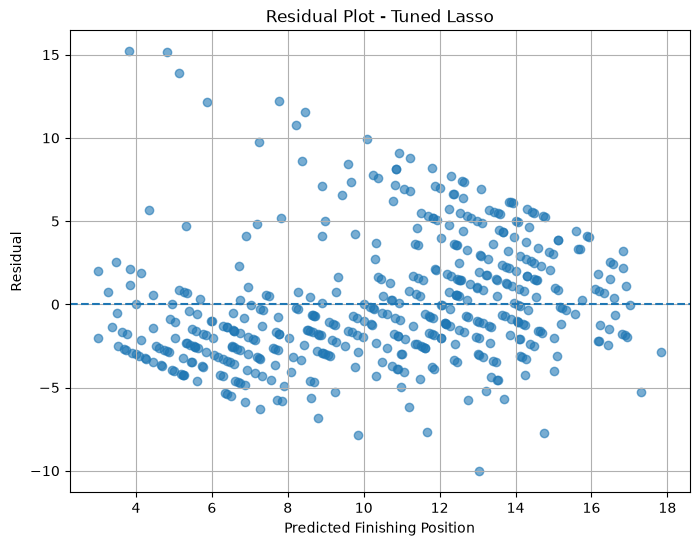

In [22]:
# Residual Plot

residuals = y_validation - tuned_lasso_val_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    tuned_lasso_val_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Finishing Position")
plt.ylabel("Residual")
plt.title("Residual Plot - Tuned Lasso")
plt.grid(True)

plt.show()

,Feature,Importance
0,qualifying_position,0.3567
1,avg_qualifying_last_5,0.1248
2,avg_finish_all_previous,0.0775
3,avg_finish_last_5,0.0708
4,avg_qualifying_all_previous,0.0693
5,career_races_before,0.0641
6,constructor_points_so_far,0.0608
7,previous_finish,0.0469
8,season_points_so_far,0.0418
9,grid,0.0396


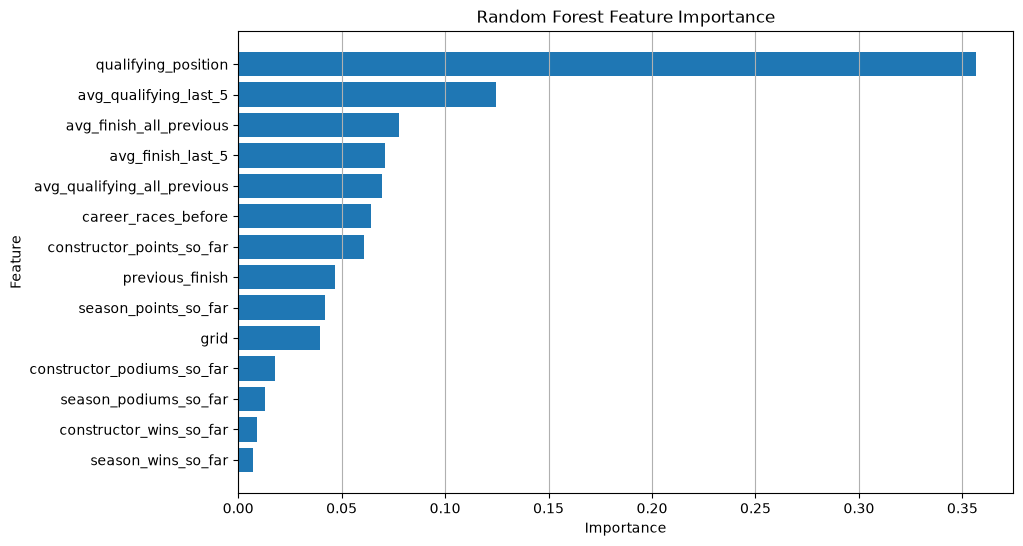

In [23]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance.round(4))

# Plot Random Forest Feature Importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()

In [24]:
# Final evaluation on untouched 2025 test data

# Predict 2025
final_test_pred = lasso_grid.predict(X_test)

# Calculate metrics
final_r2 = r2_score(y_test, final_test_pred)

final_rmse = np.sqrt(
    mean_squared_error(y_test, final_test_pred)
)

final_mae = mean_absolute_error(
    y_test, final_test_pred
)

print("Final Test Results - Tuned Lasso")
print("--------------------------------")
print("R²   :", round(final_r2, 4))
print("RMSE :", round(final_rmse, 4))
print("MAE  :", round(final_mae, 4))

Final Test Results - Tuned Lasso
--------------------------------
R²   : 0.4518
RMSE : 4.2618
MAE  : 3.3128


In [25]:
# Final Regression Summary

final_regression_summary = pd.DataFrame({
    "Stage": [
        "2024 Validation - Tuned Lasso",
        "2025 Final Test - Tuned Lasso"
    ],
    "R²": [
        tuned_lasso_r2,
        final_r2
    ],
    "RMSE": [
        tuned_lasso_rmse,
        final_rmse
    ],
    "MAE": [
        tuned_lasso_mae,
        final_mae
    ]
})

display(final_regression_summary.round(4))

,Stage,R²,RMSE,MAE
0,2024 Validation - Tuned Lasso,0.5676,3.7849,2.9587
1,2025 Final Test - Tuned Lasso,0.4518,4.2618,3.3128


In [26]:
# Save regression results

regression_results.to_csv(
    "../data/processed/regression_model_comparison.csv",
    index=False
)

final_regression_summary.to_csv(
    "../data/processed/final_regression_results.csv",
    index=False
)

print("Regression results saved successfully!")

Regression results saved successfully!
